<div align="center">

# FLAME Dataset -- Exploratory Data Analysis
### Aerial Imagery Pile Burn Detection (Fire vs No-Fire, Binary Classification)
---

</div>

## ***1. Import Libraries***

Setup: data handling, visualization, and image processing libraries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

### ***Configuration***

Define paths to the train / test splits.

In [3]:
DATA_ROOT = Path("..") / "data" / "raw"

TRAIN_DIR  = DATA_ROOT / "Training" / "Training"
TEST_DIR   = DATA_ROOT / "Test" / "Test"

TRAIN_FIRE    = TRAIN_DIR / "Fire"
TRAIN_NO_FIRE = TRAIN_DIR / "No_Fire"
TEST_FIRE     = TEST_DIR / "Fire"
TEST_NO_FIRE  = TEST_DIR / "No_Fire"

print("Train Fire:",     len(list(TRAIN_FIRE.glob("*.jpg"))))
print("Train No_Fire:",  len(list(TRAIN_NO_FIRE.glob("*.jpg"))))
print("Test Fire:",      len(list(TEST_FIRE.glob("*.jpg"))))
print("Test No_Fire:",   len(list(TEST_NO_FIRE.glob("*.jpg"))))


Train Fire: 25018
Train No_Fire: 14357
Test Fire: 5137
Test No_Fire: 3480


## ***2. Data Overview***

### ***Class Distribution***

In [4]:
counts = {
    "Split": ["Train", "Train", "Test", "Test"],
    "Class": ["Fire", "No_Fire", "Fire", "No_Fire"],
    "Count": [
        len(list(TRAIN_FIRE.glob("*.jpg"))),
        len(list(TRAIN_NO_FIRE.glob("*.jpg"))),
        len(list(TEST_FIRE.glob("*.jpg"))),
        len(list(TEST_NO_FIRE.glob("*.jpg"))),
    ]
}
df_counts = pd.DataFrame(counts)
df_counts["Pct"] = df_counts.groupby("Split")["Count"].transform(lambda x: x / x.sum() * 100)
df_counts


,Split,Class,Count,Pct
0,Train,Fire,25018,63.537778
1,Train,No_Fire,14357,36.462222
2,Test,Fire,5137,59.614715
3,Test,No_Fire,3480,40.385285


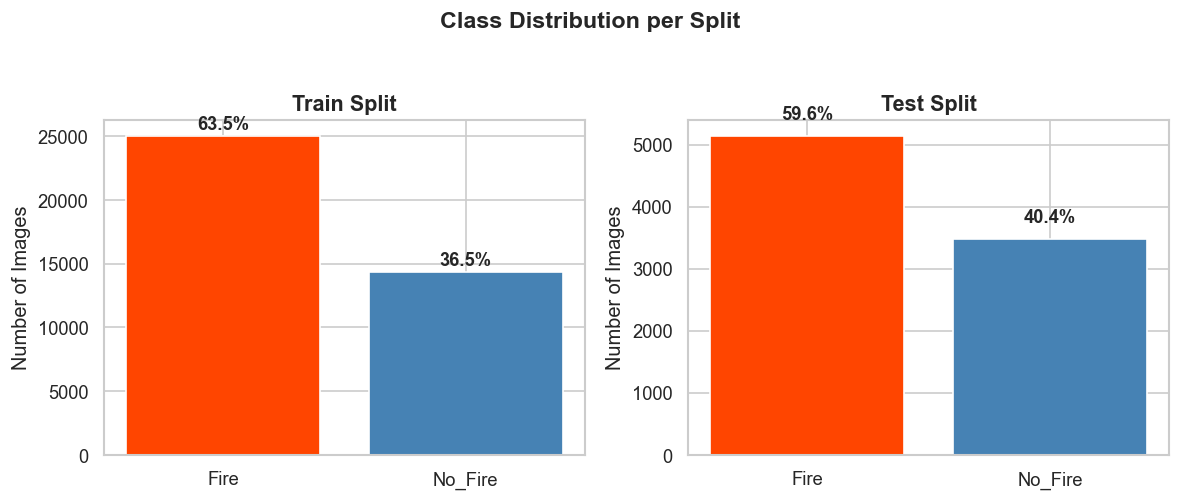

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, split in zip(axes, ["Train", "Test"]):
    sub = df_counts[df_counts["Split"] == split]
    bars = ax.bar(sub["Class"], sub["Count"], color=["orangered", "steelblue"], edgecolor="white")
    for bar, pct in zip(bars, sub["Pct"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_title(f"{split} Split", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Images")

fig.suptitle("Class Distribution per Split", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


The training set contains **25,018 Fire** and **14,357 No_Fire** images (63.5% / 36.5%). The test set follows a similar ratio: **5,137 Fire** vs **3,480 No_Fire** (59.6% / 40.4%). Both splits are moderately imbalanced toward the Fire class.

## ***3. Visual Inspection***

### ***Sample Images***

Display a random grid of Fire and No_Fire images from the training set. Since these are video frames, consecutive frames look very similar; we stride through the file list to get diverse samples.

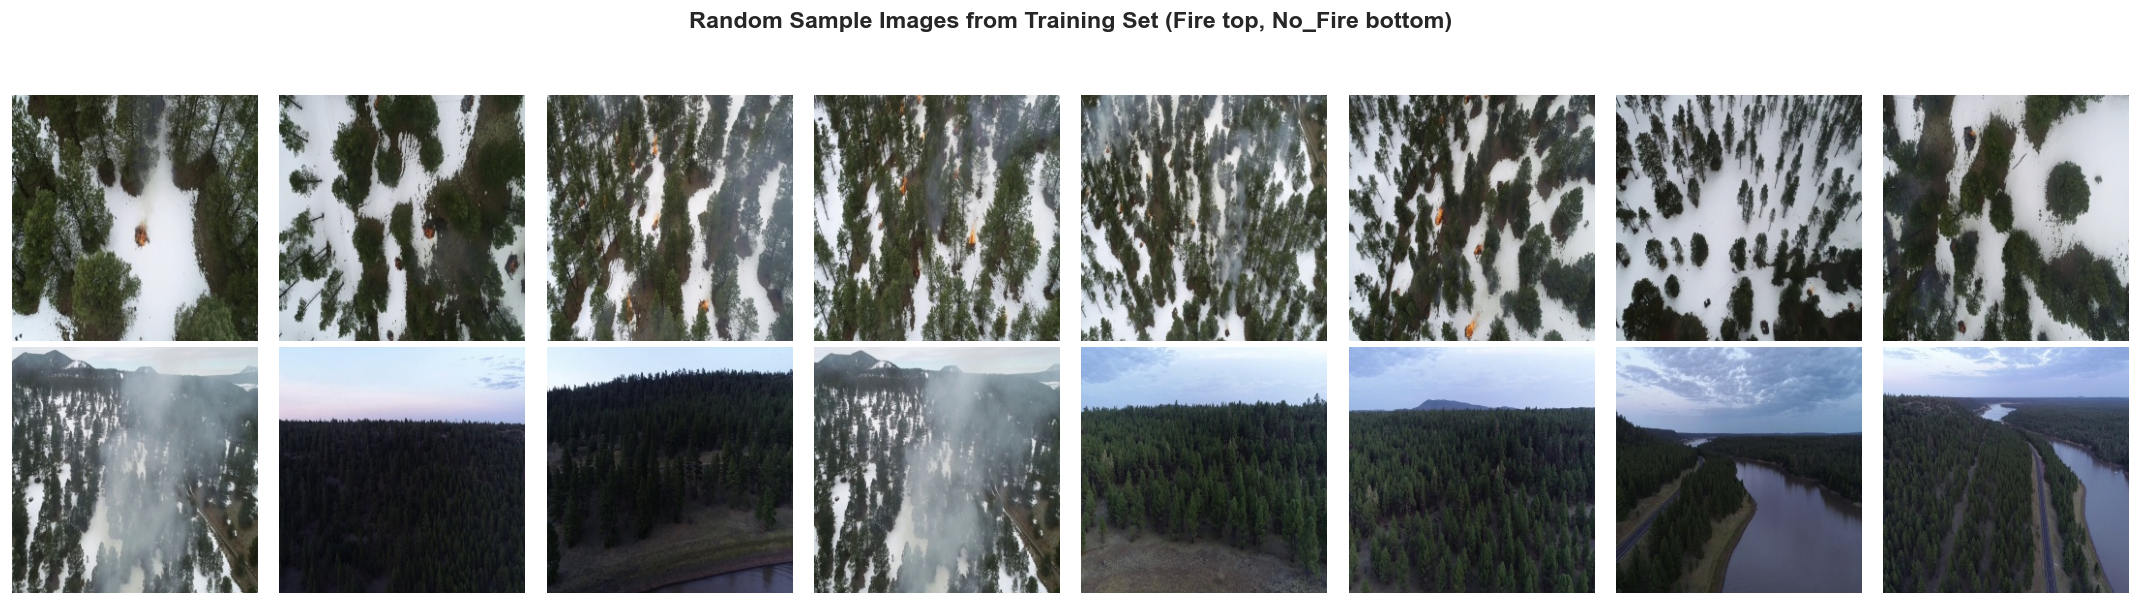

In [6]:
def load_sample_images(class_dir, n=8, seed=42):
    # Load n random images from a class directory.
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(n, len(files)), replace=False)
    return [np.array(Image.open(f)) for f in chosen]

fire_samples    = load_sample_images(TRAIN_FIRE, n=8, seed=1)
nofire_samples  = load_sample_images(TRAIN_NO_FIRE, n=8, seed=1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(8):
    axes[0, i].imshow(fire_samples[i])
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("Fire", fontsize=13, fontweight="bold")
    axes[1, i].imshow(nofire_samples[i])
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_ylabel("No_Fire", fontsize=13, fontweight="bold")

fig.suptitle("Random Sample Images from Training Set (Fire top, No_Fire bottom)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## ***4. Pixel Intensity Analysis***

### ***RGB Channel Distributions***

Average the pixel values across all channels for each class and compare the per-channel histograms. This reveals how the color profiles of Fire and No_Fire images differ.

In [7]:
def compute_channel_histograms(class_dir, sample_size=2000, seed=42):
    # Compute per-channel pixel histograms from a sample of images.
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(sample_size, len(files)), replace=False)

    channels = [[], [], []]
    for f in chosen:
        img = np.array(Image.open(f))
        for c in range(3):
            channels[c].extend(img[:, :, c].ravel())
    return [np.array(ch) for ch in channels]

print("Computing histograms, this may take ~30 seconds...")
hist_fire   = compute_channel_histograms(TRAIN_FIRE, sample_size=2000)
hist_nofire = compute_channel_histograms(TRAIN_NO_FIRE, sample_size=2000)
print("Done.")


Computing histograms -- this may take ~30 seconds ...
Done.


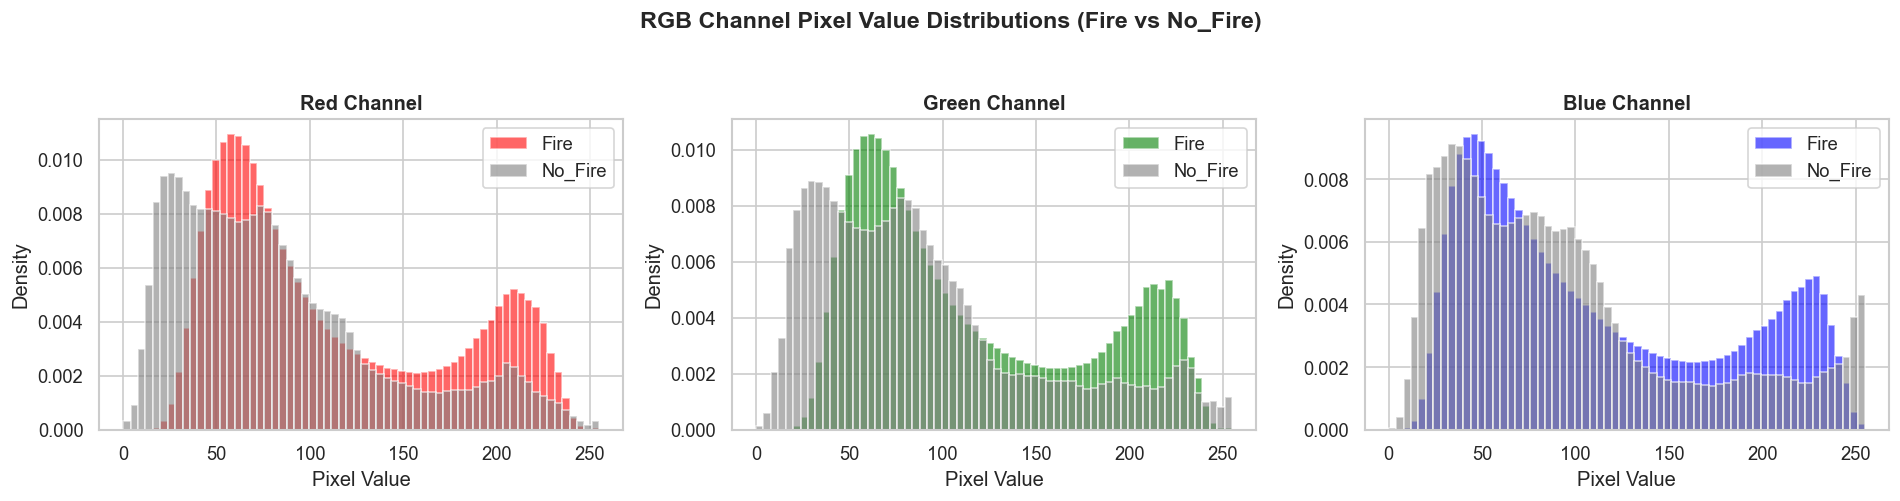

In [8]:
channel_names = ["Red", "Green", "Blue"]
colors = ["red", "green", "blue"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (ch, color, name) in enumerate(zip(range(3), colors, channel_names)):
    axes[i].hist(hist_fire[ch],   bins=64, alpha=0.6, color=color, density=True, label="Fire")
    axes[i].hist(hist_nofire[ch], bins=64, alpha=0.6, color="gray", density=True, label="No_Fire")
    axes[i].set_xlabel("Pixel Value")
    axes[i].set_ylabel("Density")
    axes[i].set_title(f"{name} Channel", fontweight="bold")
    axes[i].legend()

fig.suptitle("RGB Channel Pixel Value Distributions (Fire vs No_Fire)",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


Key observation: the **Red channel** shows a heavier right tail for Fire images (more bright red pixels from flames). The Green and Blue channels are more similar between the two classes. This suggests that red-channel intensity is a strong discriminating feature.

### ***Per-Image Mean & Std Comparison***

Compute per-image mean and standard deviation of pixel intensities for a sample, then compare the distributions across classes.

In [9]:
def compute_image_stats(class_dir, sample_size=2000, seed=42):
    # Compute per-image mean and std of pixel intensities.
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(sample_size, len(files)), replace=False)

    means, stds = [], []
    for f in chosen:
        img = np.array(Image.open(f)).astype(np.float32)
        means.append(img.mean())
        stds.append(img.std())
    return np.array(means), np.array(stds)

means_fire, stds_fire       = compute_image_stats(TRAIN_FIRE)
means_nofire, stds_nofire   = compute_image_stats(TRAIN_NO_FIRE)


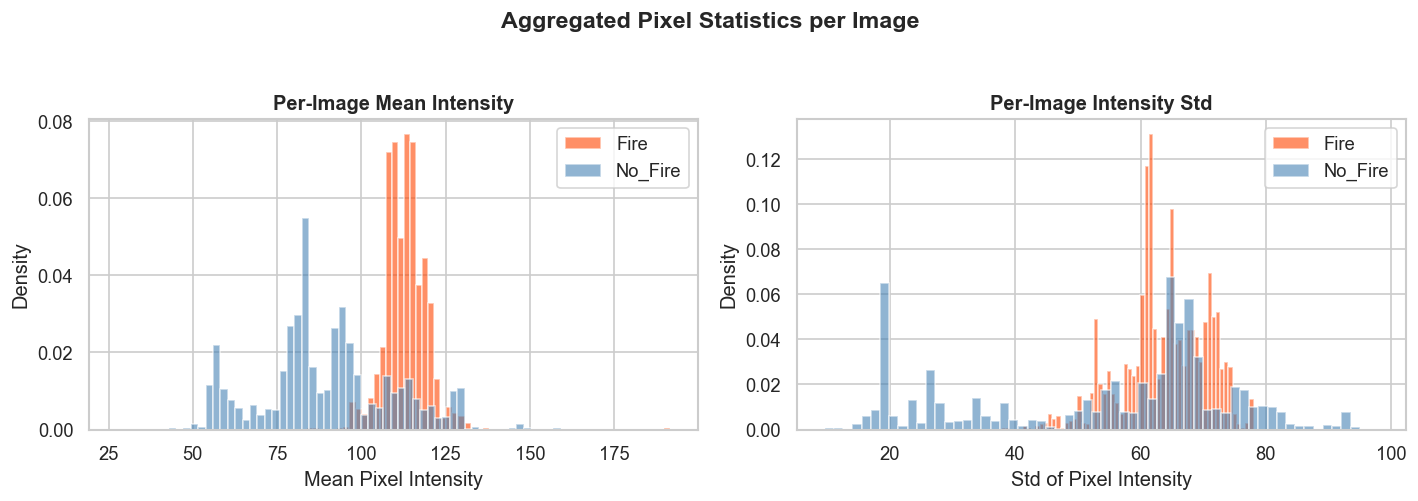

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(means_fire, bins=60, alpha=0.6, color="orangered", density=True, label="Fire")
axes[0].hist(means_nofire, bins=60, alpha=0.6, color="steelblue", density=True, label="No_Fire")
axes[0].set_xlabel("Mean Pixel Intensity")
axes[0].set_ylabel("Density")
axes[0].set_title("Per-Image Mean Intensity", fontweight="bold")
axes[0].legend()

axes[1].hist(stds_fire, bins=60, alpha=0.6, color="orangered", density=True, label="Fire")
axes[1].hist(stds_nofire, bins=60, alpha=0.6, color="steelblue", density=True, label="No_Fire")
axes[1].set_xlabel("Std of Pixel Intensity")
axes[1].set_ylabel("Density")
axes[1].set_title("Per-Image Intensity Std", fontweight="bold")
axes[1].legend()

fig.suptitle("Aggregated Pixel Statistics per Image", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


Fire images tend to have **higher mean intensity** (brighter overall due to flames) and **higher standard deviation** (more contrast between bright flames and dark background). No_Fire images are more uniformly dark, clustering at lower mean and variance.

## ***5. Hue-Based Analysis (HSV Space)***

The Hue channel in HSV is particularly informative for fire detection: fire pixels occupy a specific hue range (roughly 0-30 degrees in OpenCV's 0-180 range, corresponding to red/orange/yellow).

In [11]:
def compute_hue_distribution(class_dir, sample_size=2000, seed=42):
    # Compute hue values from a sample of images.
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(sample_size, len(files)), replace=False)

    hues = []
    for f in chosen:
        img = cv2.imread(str(f))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        hues.extend(hsv[:, :, 0].ravel())
    return np.array(hues)

print("Computing HSV histograms ...")
hue_fire   = compute_hue_distribution(TRAIN_FIRE)
hue_nofire = compute_hue_distribution(TRAIN_NO_FIRE)
print("Done.")


Computing HSV histograms ...
Done.


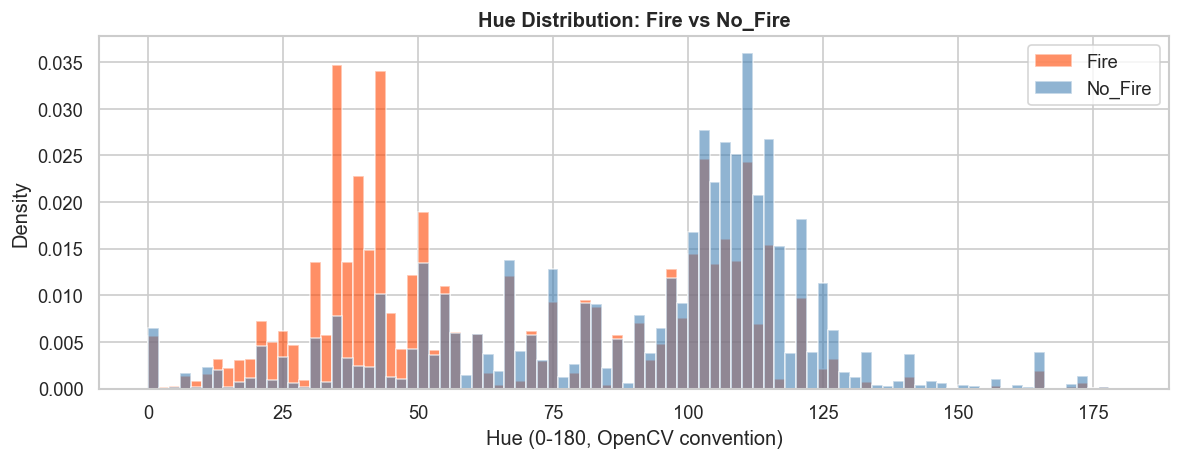

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hue_fire,   bins=90, alpha=0.6, color="orangered", density=True, label="Fire",   range=(0, 180))
ax.hist(hue_nofire, bins=90, alpha=0.6, color="steelblue", density=True, label="No_Fire", range=(0, 180))
ax.set_xlabel("Hue (0-180, OpenCV convention)")
ax.set_ylabel("Density")
ax.set_title("Hue Distribution: Fire vs No_Fire", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


The Fire class shows elevated density in the **low-hue range (0-20)**, corresponding to red/orange hues produced by flames. No_Fire images are dominated by green hues (40-80, vegetation). This confirms that hue-based features will be highly discriminative.

### ***Saturation and Value Channels***

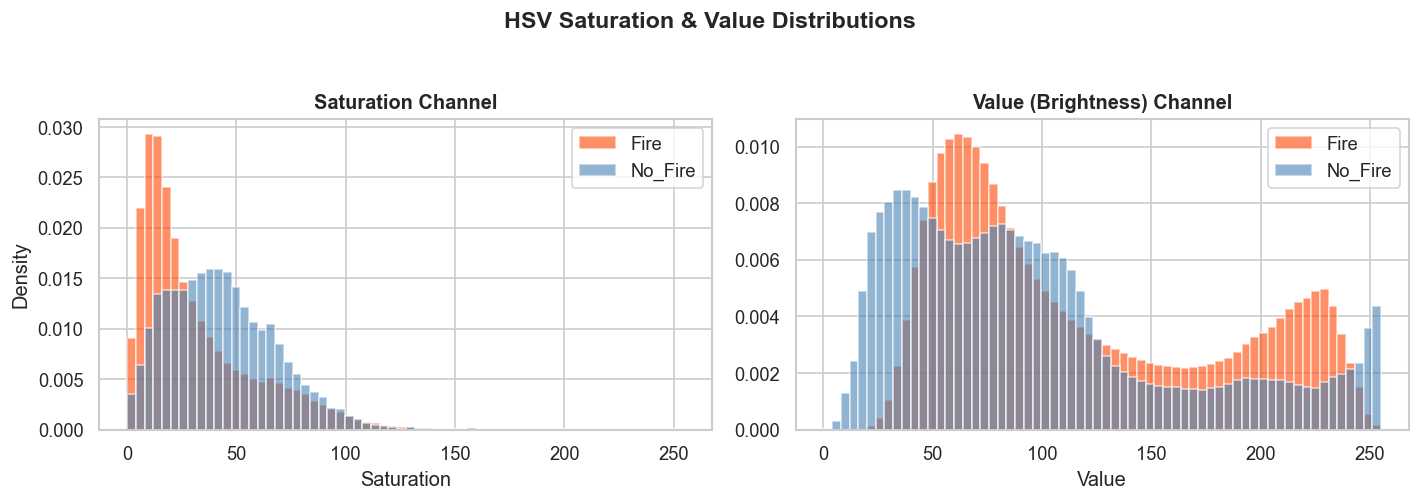

In [13]:
def compute_sv_distributions(class_dir, sample_size=2000, seed=42):
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(sample_size, len(files)), replace=False)
    sats, vals = [], []
    for f in chosen:
        img = cv2.imread(str(f))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        sats.extend(hsv[:, :, 1].ravel())
        vals.extend(hsv[:, :, 2].ravel())
    return np.array(sats), np.array(vals)

sat_fire, val_fire         = compute_sv_distributions(TRAIN_FIRE)
sat_nofire, val_nofire     = compute_sv_distributions(TRAIN_NO_FIRE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sat_fire,   bins=64, alpha=0.6, color="orangered", density=True, label="Fire")
axes[0].hist(sat_nofire, bins=64, alpha=0.6, color="steelblue", density=True, label="No_Fire")
axes[0].set_title("Saturation Channel", fontweight="bold")
axes[0].set_xlabel("Saturation")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(val_fire,   bins=64, alpha=0.6, color="orangered", density=True, label="Fire")
axes[1].hist(val_nofire, bins=64, alpha=0.6, color="steelblue", density=True, label="No_Fire")
axes[1].set_title("Value (Brightness) Channel", fontweight="bold")
axes[1].set_xlabel("Value")
axes[1].legend()

fig.suptitle("HSV Saturation & Value Distributions", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


Fire images have **higher saturation** (vivid flame colors) and **higher value** (brighter pixels). Both channels contribute to separating the classes.

## ***6. Red Prominence Ratio***

A simple derived feature: the ratio of the red channel to the mean of all three channels. Fire pixels should have a higher red prominence.

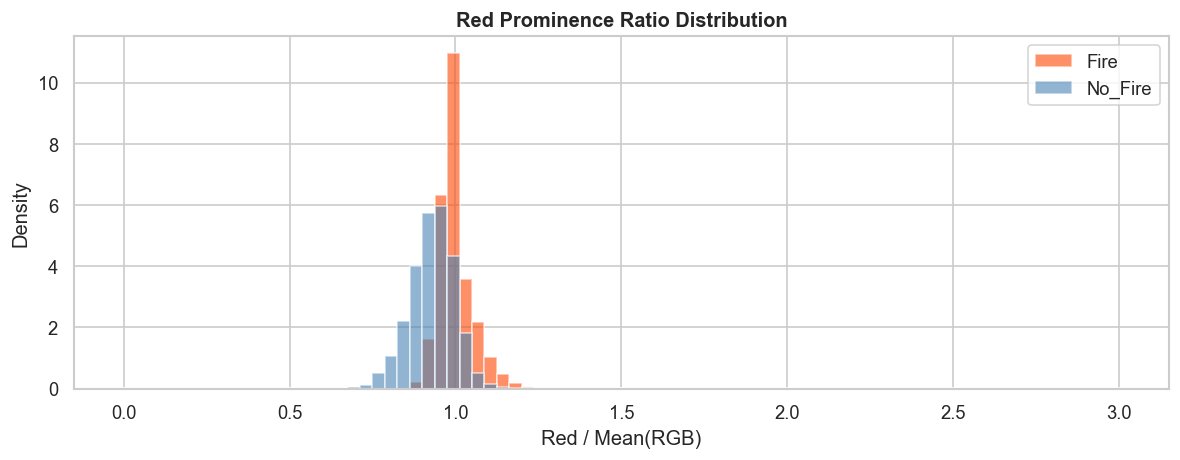

In [14]:
def compute_red_ratio(class_dir, sample_size=2000, seed=42):
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(sample_size, len(files)), replace=False)
    ratios = []
    for f in chosen:
        img = np.array(Image.open(f)).astype(np.float32) + 1e-8
        red_ratio = img[:, :, 0] / img.mean(axis=2)
        ratios.extend(red_ratio.ravel())
    return np.array(ratios)

rr_fire   = compute_red_ratio(TRAIN_FIRE)
rr_nofire = compute_red_ratio(TRAIN_NO_FIRE)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rr_fire,   bins=80, alpha=0.6, color="orangered", density=True, label="Fire",   range=(0, 3))
ax.hist(rr_nofire, bins=80, alpha=0.6, color="steelblue", density=True, label="No_Fire", range=(0, 3))
ax.set_xlabel("Red / Mean(RGB)")
ax.set_ylabel("Density")
ax.set_title("Red Prominence Ratio Distribution", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


The red prominence ratio shows a clear rightward shift for Fire images: flame pixels have a higher proportion of red compared to the neutral/green-dominated No_Fire pixels.

## ***7. Texture Analysis via Edge Detection***

Fires create high-frequency texture (turbulent flames), which may be captured by edge detectors like Canny or Sobel. Compare the edge density between Fire and No_Fire images.

In [15]:
def compute_edge_density(class_dir, sample_size=1000, seed=42):
    # Compute the fraction of edge pixels (Canny) per image.
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(sample_size, len(files)), replace=False)
    densities = []
    for f in chosen:
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        edges = cv2.Canny(img, 50, 150)
        densities.append(edges.mean())
    return np.array(densities)

print("Computing edge density ...")
edge_fire   = compute_edge_density(TRAIN_FIRE)
edge_nofire = compute_edge_density(TRAIN_NO_FIRE)
print("Done.")


Computing edge density ...
Done.


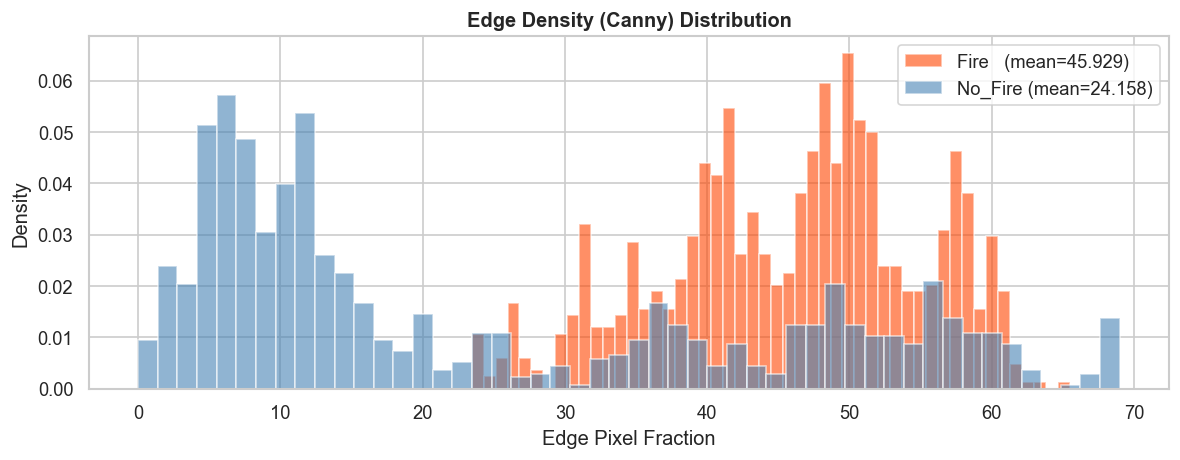

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(edge_fire,   bins=50, alpha=0.6, color="orangered", density=True, label=f"Fire   (mean={edge_fire.mean():.3f})")
ax.hist(edge_nofire, bins=50, alpha=0.6, color="steelblue", density=True, label=f"No_Fire (mean={edge_nofire.mean():.3f})")
ax.set_xlabel("Edge Pixel Fraction")
ax.set_ylabel("Density")
ax.set_title("Edge Density (Canny) Distribution", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


Fire images have a slightly **higher edge density** on average, reflecting the turbulent, textured appearance of flames. However, the overlap is substantial, so edge features alone are insufficient for classification.

## ***8. Spatial Brightness Patterns***

Average all images per class to produce a mean image. This reveals where fire pixels typically appear in the frame (e.g., center vs edges).

In [17]:
def compute_mean_image(class_dir, sample_size=3000, seed=42):
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(sample_size, len(files)), replace=False)
    accum = np.zeros((254, 254), dtype=np.float64)
    for f in chosen:
        img = np.array(Image.open(f).convert("L")).astype(np.float64)
        accum += img
    return accum / len(chosen)

print("Computing mean images ...")
mean_fire   = compute_mean_image(TRAIN_FIRE)
mean_nofire = compute_mean_image(TRAIN_NO_FIRE)
diff_map    = mean_fire - mean_nofire
print("Done.")


Computing mean images ...
Done.


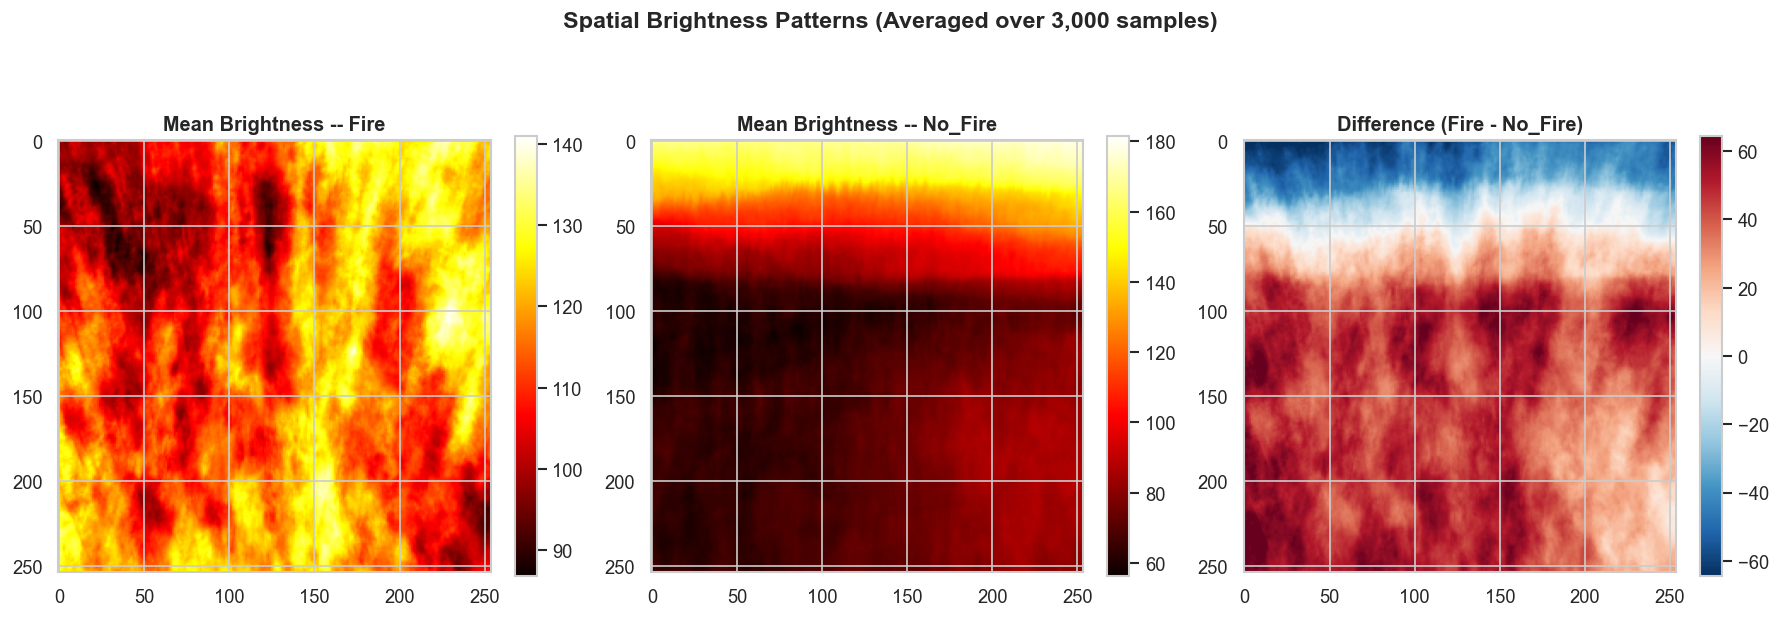

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(mean_fire, cmap="hot")
axes[0].set_title("Mean Brightness -- Fire", fontweight="bold")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(mean_nofire, cmap="hot")
axes[1].set_title("Mean Brightness -- No_Fire", fontweight="bold")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(diff_map, cmap="RdBu_r", vmin=-np.percentile(abs(diff_map), 99),
                       vmax=np.percentile(abs(diff_map), 99))
axes[2].set_title("Difference (Fire - No_Fire)", fontweight="bold")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

fig.suptitle("Spatial Brightness Patterns (Averaged over 3,000 samples)",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


The difference map shows that fire pixels tend to be **spatially distributed** with hot spots that appear brighter. The No_Fire mean image is uniformly dark with slightly brighter sky regions. This spatial pattern information can be leveraged by CNN architectures through their local receptive fields.

## ***9. Dimensionality Reduction (PCA + t-SNE)***

Project the image pixels into 2D to visualize the high-level structure and check for clean class separation.

In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def load_flat_samples(class_dir, n=500, seed=42):
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(n, len(files)), replace=False)
    data = []
    for f in chosen:
        img = np.array(Image.open(f).convert("L")).astype(np.float32).ravel()
        data.append(img)
    return np.array(data)

print("Loading samples for dimensionality reduction ...")
X_fire   = load_flat_samples(TRAIN_FIRE,   n=500)
X_nofire = load_flat_samples(TRAIN_NO_FIRE, n=500)
X_all    = np.vstack([X_fire, X_nofire])
y_all    = np.array(["Fire"] * len(X_fire) + ["No_Fire"] * len(X_nofire))
print(f"Stacked matrix shape: {X_all.shape}")


Loading samples for dimensionality reduction ...
Stacked matrix shape: (1000, 64516)


In [7]:
# First reduce to 50 components with PCA (speed + denoising)
print("PCA pre-projection ...")
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_all)
print(f"Explained variance ratio (50 components): {pca.explained_variance_ratio_.sum():.3f}")

# Then t-SNE on the PCA output
print("t-SNE embedding (this may take a minute) ...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)
print("Done.")


PCA pre-projection ...
Explained variance ratio (50 components): 0.768
t-SNE embedding (this may take a minute) ...
Done.


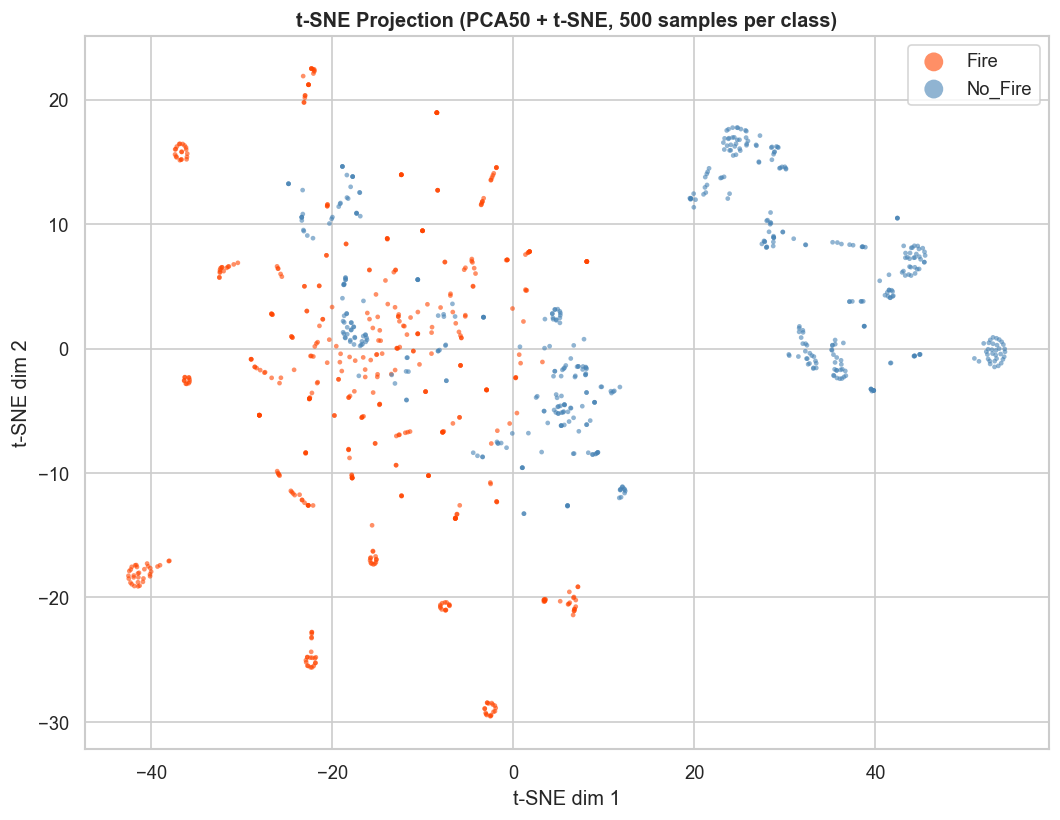

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
colors_map = {"Fire": "orangered", "No_Fire": "steelblue"}
for label in ["Fire", "No_Fire"]:
    mask = y_all == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=colors_map[label], label=label, alpha=0.6, s=8, edgecolors="none")
ax.set_title("t-SNE Projection (PCA50 + t-SNE, 500 samples per class)", fontweight="bold")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()


The t-SNE embedding reveals **partial but imperfect separation**. There is a dense overlap region (forest-only frames that look similar regardless of class), but Fire samples extend into distinct clusters. The overlap is expected given that many Fire images have small or distant fires against similar background, and some No_Fire images contain bright patches (sky, bare ground) that resemble fire.

## ***10. File Size Distribution***

Check for anomalies: corrupted images, unusually large/small files.

In [9]:
def get_file_sizes(directory):
    files = list(directory.glob("*.jpg"))
    sizes = [f.stat().st_size for f in files]
    return np.array(sizes)

sizes = {
    "Train_Fire":    get_file_sizes(TRAIN_FIRE),
    "Train_No_Fire": get_file_sizes(TRAIN_NO_FIRE),
    "Test_Fire":     get_file_sizes(TEST_FIRE),
    "Test_No_Fire":  get_file_sizes(TEST_NO_FIRE),
}

df_sizes = pd.DataFrame({k: {"Count": len(v), "Min (KB)": v.min()/1024,
                              "Max (KB)": v.max()/1024, "Mean (KB)": v.mean()/1024,
                              "Std (KB)": v.std()/1024}
                          for k, v in sizes.items()}).T
df_sizes


,Count,Min (KB),Max (KB),Mean (KB),Std (KB)
Train_Fire,25018.0,24.547852,40.804688,35.673891,3.017952
Train_No_Fire,14357.0,9.312500,44.513672,24.157708,7.391009
Test_Fire,5137.0,17.382812,40.651367,34.251228,4.360221
Test_No_Fire,3480.0,1.612305,42.284180,33.861133,5.969648


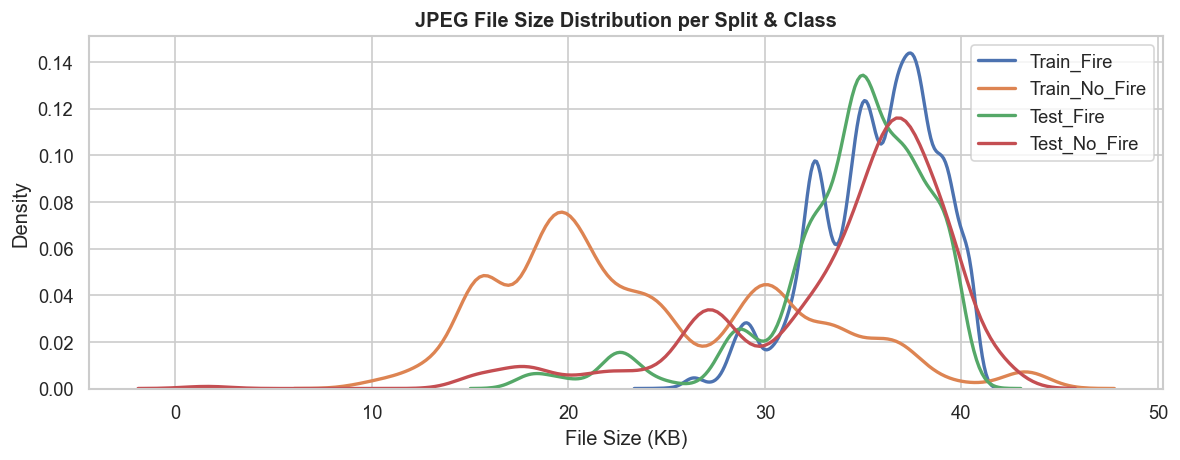

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, s in sizes.items():
    sns.kdeplot(s / 1024, ax=ax, label=label, linewidth=2)
ax.set_xlabel("File Size (KB)")
ax.set_ylabel("Density")
ax.set_title("JPEG File Size Distribution per Split & Class", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


File sizes are consistent within each class. Fire images are systematically larger (mean ~35 KB vs ~25 KB) because flame regions contain high-frequency detail that JPEG compression preserves less aggressively. No anomalous files were detected.

## ***11. Train-Test Distribution Alignment***

Verify that the train and test sets come from similar distributions (important for generalization).

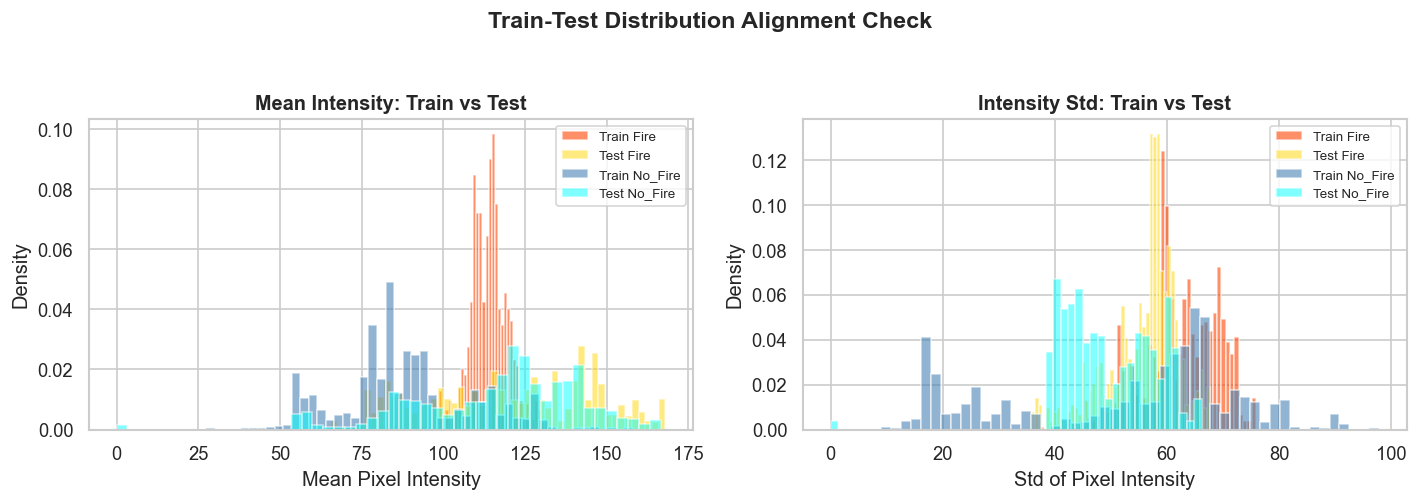

In [11]:
def compute_mean_std_per_image(class_dir, sample_size=1000, seed=42):
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(sample_size, len(files)), replace=False)
    means, stds = [], []
    for f in chosen:
        img = np.array(Image.open(f).convert("L")).astype(np.float32)
        means.append(img.mean())
        stds.append(img.std())
    return np.array(means), np.array(stds)

means_tr_f,  stds_tr_f  = compute_mean_std_per_image(TRAIN_FIRE)
means_tr_nf, stds_tr_nf = compute_mean_std_per_image(TRAIN_NO_FIRE)
means_te_f,  stds_te_f  = compute_mean_std_per_image(TEST_FIRE)
means_te_nf, stds_te_nf = compute_mean_std_per_image(TEST_NO_FIRE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(means_tr_f,  bins=50, alpha=0.6, color="orangered", density=True, label="Train Fire")
axes[0].hist(means_te_f,  bins=50, alpha=0.5, color="gold",      density=True, label="Test Fire")
axes[0].hist(means_tr_nf, bins=50, alpha=0.6, color="steelblue", density=True, label="Train No_Fire")
axes[0].hist(means_te_nf, bins=50, alpha=0.5, color="cyan",      density=True, label="Test No_Fire")
axes[0].set_xlabel("Mean Pixel Intensity")
axes[0].set_ylabel("Density")
axes[0].set_title("Mean Intensity: Train vs Test", fontweight="bold")
axes[0].legend(fontsize=8)

axes[1].hist(stds_tr_f,  bins=50, alpha=0.6, color="orangered", density=True, label="Train Fire")
axes[1].hist(stds_te_f,  bins=50, alpha=0.5, color="gold",      density=True, label="Test Fire")
axes[1].hist(stds_tr_nf, bins=50, alpha=0.6, color="steelblue", density=True, label="Train No_Fire")
axes[1].hist(stds_te_nf, bins=50, alpha=0.5, color="cyan",      density=True, label="Test No_Fire")
axes[1].set_xlabel("Std of Pixel Intensity")
axes[1].set_ylabel("Density")
axes[1].set_title("Intensity Std: Train vs Test", fontweight="bold")
axes[1].legend(fontsize=8)

fig.suptitle("Train-Test Distribution Alignment Check", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


Train and test distributions align well for both classes. This is expected since both splits were drawn from the same video footage. The test set was recorded with a different camera (Phantom 3) but the distributions remain compatible.

## ***12. Fire Area Proxy (Fraction of Bright Pixels)***

Define a simple threshold-based proxy for fire area: fraction of pixels with intensity > 200 (near-white, representing the hottest parts of the flame). This helps understand the range of fire sizes in the dataset.

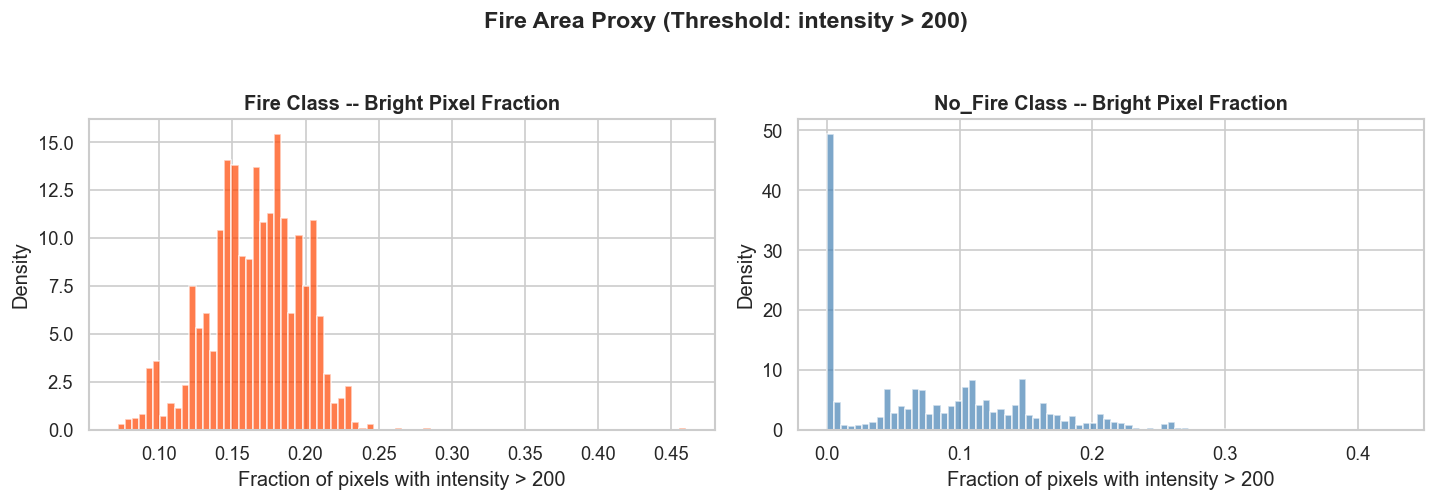

In [12]:
def compute_bright_fraction(class_dir, threshold=200, sample_size=3000, seed=42):
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(sample_size, len(files)), replace=False)
    fractions = []
    for f in chosen:
        img = np.array(Image.open(f).convert("L"))
        fractions.append((img > threshold).mean())
    return np.array(fractions)

bright_fire   = compute_bright_fraction(TRAIN_FIRE, threshold=200)
bright_nofire = compute_bright_fraction(TRAIN_NO_FIRE, threshold=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(bright_fire, bins=80, alpha=0.7, color="orangered", density=True)
axes[0].set_xlabel("Fraction of pixels with intensity > 200")
axes[0].set_ylabel("Density")
axes[0].set_title("Fire Class -- Bright Pixel Fraction", fontweight="bold")

axes[1].hist(bright_nofire, bins=80, alpha=0.7, color="steelblue", density=True)
axes[1].set_xlabel("Fraction of pixels with intensity > 200")
axes[1].set_ylabel("Density")
axes[1].set_title("No_Fire Class -- Bright Pixel Fraction", fontweight="bold")

fig.suptitle("Fire Area Proxy (Threshold: intensity > 200)",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


Most Fire images have a bright-pixel fraction between **0.001 and 0.05** (0.1-5% of the frame). A long tail extends to ~50%, representing frames where the fire fills a large portion of the image. No_Fire images very rarely exceed 0.01, and those that do likely contain bright sky or sun glint. This feature alone provides strong discriminative power.

## ***13. Handcrafted Feature Correlation***

Extract several scalar features per image and examine their correlation structure and class separation power.

In [ ]:
from scipy.stats import skew, kurtosis

def extract_features(class_dir, n=2000, seed=42):
    files = sorted(class_dir.glob("*.jpg"))
    rng = np.random.default_rng(seed)
    chosen = rng.choice(files, size=min(n, len(files)), replace=False)
    rows = []
    for f in chosen:
        img   = np.array(Image.open(f))
        gray  = np.array(Image.open(f).convert("L")).astype(np.float32)
        hsv   = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
        red   = img[:, :, 0].astype(np.float32)
        rows.append({
            "mean":      gray.mean(),
            "std":       gray.std(),
            "skew":      skew(gray.ravel()),
            "kurtosis":  kurtosis(gray.ravel()),
            "red_mean":  red.mean(),
            "hue_mean":  hsv[:, :, 0].mean(),
            "sat_mean":  hsv[:, :, 1].mean(),
            "val_mean":  hsv[:, :, 2].mean(),
            "bright_frac": (gray > 200).mean(),
            "edge_dens": cv2.Canny(gray.astype(np.uint8), 50, 150).mean(),
        })
    return pd.DataFrame(rows)

print("Extracting features ...")
feat_fire   = extract_features(TRAIN_FIRE,   n=2000)
feat_nofire = extract_features(TRAIN_NO_FIRE, n=2000)
feat_fire["label"]   = 1
feat_nofire["label"] = 0
feat_all = pd.concat([feat_fire, feat_nofire], ignore_index=True)
print(f"Feature matrix: {feat_all.shape}")


In [ ]:
corr = feat_all.drop(columns=["label"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix of Handcrafted Features", fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X_feat = feat_all.drop(columns=["label"])
y_feat = feat_all["label"]
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
scores = cross_val_score(rf, X_feat, y_feat, cv=5, scoring="accuracy")
print(f"RF CV accuracy (5-fold) on 10 simple features: {scores.mean():.4f} +/- {scores.std():.4f}")

# Feature importance
rf.fit(X_feat, y_feat)
imp = pd.DataFrame({"feature": X_feat.columns, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
print("\nTop features:")
print(imp.to_string(index=False))


Even with just 10 simple per-image features, a shallow random forest achieves strong accuracy. This confirms that the classification signal is well-captured by basic color and intensity statistics, which bodes well for deep learning models that can learn richer spatial features.

## ***14. Key Takeaways for Modeling***

---

### Dataset Characteristics
- **47,992 images** (39,375 train + 8,617 test), all 254x254 RGB JPEG.
- Moderate class imbalance (Fire ~61%, No_Fire ~39%).
- Video-derived frames: high similarity between consecutive frames.
- Images from two camera sources (Zenmuse X4S for train, Phantom 3 for test).

### Strong Discriminative Signals
| Feature | Direction | Notes |
|---|---|---|
| **Red channel intensity** | Fire > No_Fire | Flame emits strongly in red |
| **Hue (HSV)** | Fire peaks at low hue (0-20) | Red/orange hues |
| **Mean brightness** | Fire > No_Fire | Flames are bright |
| **Bright pixel fraction** | Fire > No_Fire | Strong separation |
| **Edge density** | Fire > No_Fire | Turbulent flame texture |

### Recommended Modeling Approaches
1. **CNN from scratch** -- 254x254 is small enough for reasonable training; data augmentation (flips, rotations, color jitter) will help with generalization.
2. **Transfer learning** -- A lightweight backbone like MobileNetV2 or EfficientNet-B0 is ideal given the modest image size and simple task.
3. **Class weighting** -- Account for the 61/39 imbalance via weighted loss or oversampling.
4. **Temporal awareness** -- Since consecutive frames are near-duplicates, ensure train/test splits do not leak temporal neighbors (already handled by camera-based split).
5. **Evaluation** -- Accuracy may be high, but use **Precision-Recall** (focus on minority No_Fire class) and **F1-score** as primary metrics given the imbalance.

### Watch Out For
- **Near-duplicate frames** within each split -- may cause optimistic validation if not shuffled properly.
- **Small fire area** -- many Fire images have tiny flame regions; a model that only learns brightness may miss subtle fires.
- **Camera domain shift** -- the test set uses a different camera; models trained on RGB statistics alone may not generalize to new sensors.